# Tuned HistGradientBoosting Regression Model
## T2 Immunological Data
### Target: pain_under_load_reduction_pct

In [1]:
import sys, os
sys.path.insert(0, '../src')
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport
import joblib, os
import preprocess
import explore
import model
import model_hgbr
from sklearn.preprocessing import PowerTransformer
os.environ['PYTHONWARNINGS'] = 'ignore'

# Path to save results
MODEL_DIR = os.path.abspath('../models/pain-reduction')

In [2]:
# Running through preprocessing steps
# Load raw data
df_im, df_cl = explore.load_data()

# Clean datasets
_im_id_cols = ['Patient', 'Timepoint', 'Date']
df_im_vis   = preprocess.clean_im(df_im, False)
df_cl_vis   = preprocess.clean_cl(df_cl, False)

# Immunological: drop >25% NaN columns, remove confirmed outliers
df_im_mod    = preprocess.remove_nan_cols(df_im_vis, verbose=False)
df_im_mod    = preprocess.remove_outlier_observations(df_im_mod, verbose=False)
df_im_mod    = preprocess.remove_for_modeling(df_im_mod, verbose=False)

# Clinical: drop >25% NaN columns
df_cl_mod    = preprocess.remove_nan_cols(df_cl_vis, verbose=False)
df_cl_mod    = preprocess.remove_outlier_observations(df_cl_mod, verbose=False)
df_cl_mod    = preprocess.remove_for_modeling(df_cl_mod, verbose=False)



In [3]:
# Constructing targets:
print('\nConstructing regression targets from clinical data')
pain_scale_red = model.construct_datasets_targets(df_cl_mod, 'pain_scale', [1, 2])

# Constructing dataset for modeling with targets and im + cl data
print('\nConstructing datasets for modeling:')
df_pain = model.create_model_datasets(df_im_mod, df_cl_mod, pain_scale_red, timepoints=[2])

pt = PowerTransformer(method='yeo-johnson', standardize=True)


Constructing regression targets from clinical data

  Target distributions:
    pain_reduction                              mean=1.382  std=2.061  [-4.000, 7.100]
    pain_reduction_pct                          mean=19.720  std=33.059  [-100.000, 87.654]

Constructing datasets for modeling:

Modeling dataset ready: T2 features + clinical features
Shape: (129, 95),  Patients: 129


## HGBR Model + MRMR Feature Selection
### + Optuna Hyperparameter Tuning

In [4]:
importlib.reload(model_hgbr)
hgbr_red_results, hgbr_feature_freq, hgbr_per_fold  = model_hgbr.hgbr_mrmr(
        df_pain,
        target_col='pain_reduction_pct',
        random_state=42,
        target_transformer=pt)

joblib.dump(hgbr_feature_freq, os.path.join(MODEL_DIR, 'hgbr_feature_freq.pkl'))
joblib.dump(hgbr_per_fold, os.path.join(MODEL_DIR, 'hgbr_per_fold.pkl'))


 Nested CV - HGBR + MRMR + Optuna — pain_reduction_pct
  n=129, p=92
  Outer 4×5=20 | Inner 4×5=20 | Optuna Trials Model=50 | Optuna Trials MRMR=20

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
    MRMR Trial  1/20: RMSE=1.1710  {'K': 15, 'n_estimators': 100, 'max_depth': 8, 'min_samples_leaf': 14}
    MRMR Trial  2/20: RMSE=1.2373  {'K': 20, 'n_estimators': 100, 'max_depth': 4, 'min_samples_leaf': 13}
    MRMR Trial  3/20: RMSE=1.2333  {'K': 20, 'n_estimators': 400, 'max_depth': 7, 'min_samples_leaf': 8}
    MRMR Trial  4/20: RMSE=1.1918  {'K': 15, 'n_estimators': 400, 'max_depth': 8, 'min_samples_leaf': 17}
    MRMR Trial  5/20: RMSE=1.2585  {'K': 20, 'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 9}
    MRMR Trial  6/20: RMSE=1.2428  {'K': 10, 'n_estimators': 300, 'max_depth': 8, 'min_samples_leaf': 19}
    MRMR Trial  7/20: RMSE=1.1950  {'K': 15, 'n_estimators': 400, 

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\hgbr_per_fold.pkl']

### Plot of Feature Frequency List
Top 25 selections shown in plot.

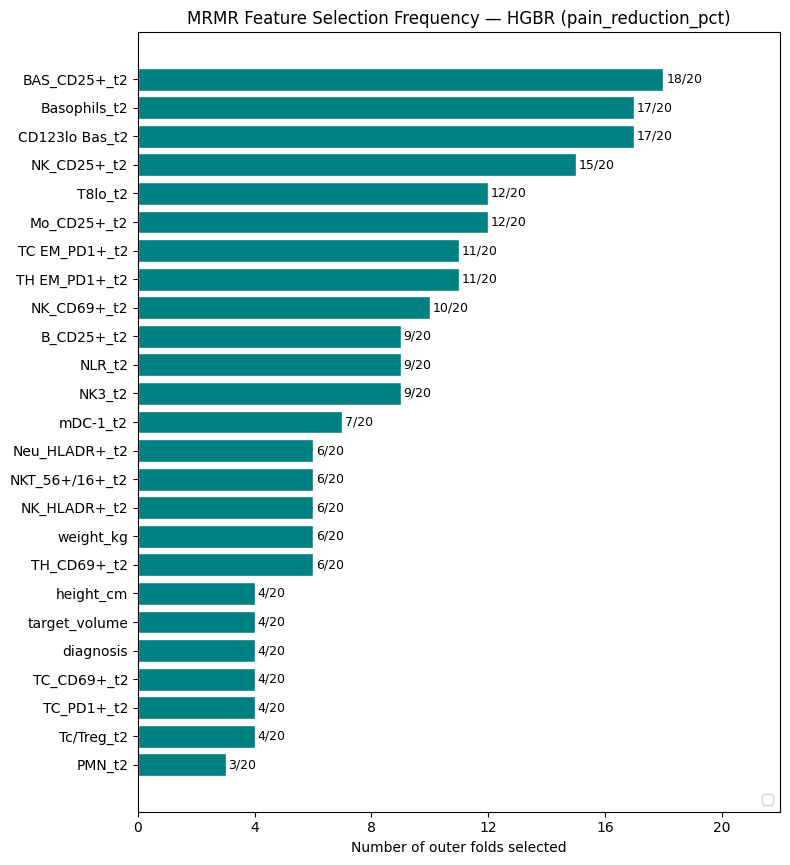

In [6]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'hgbr_feature_freq.pkl'))
model.plot_feature_frequency(feature_list, name='HGBR (pain_reduction_pct)', top=25)

## Jaccard Index of Selected Features
### Pariwise Comparisons for Each Outer Fold (20x20)


  Jaccard Scores — HGBR (MRMR Feat. Sel.)
  Folds: 20   Pairs evaluated: 190
  Mean Jaccard : 0.275 ± 0.129
  Min  Jaccard : 0.000
  Max  Jaccard : 0.818


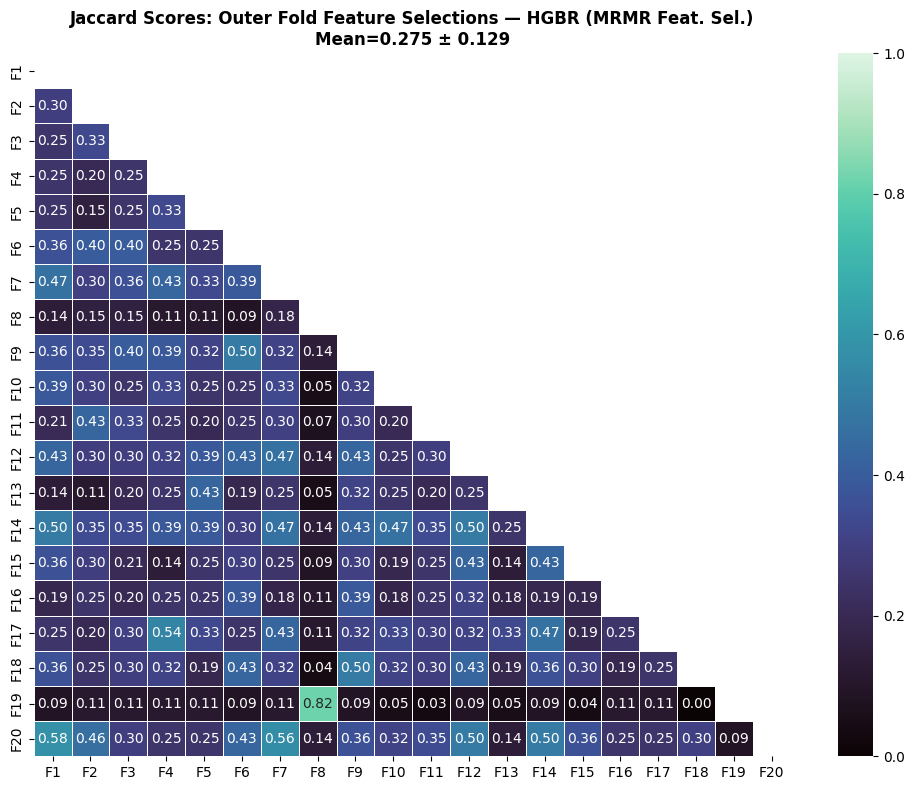

In [7]:
selected_per_fold = joblib.load(os.path.join(MODEL_DIR, 'hgbr_per_fold.pkl'))
jac_matrix = model.jaccard_scores(selected_per_fold, name='HGBR (MRMR Feat. Sel.)')

## HGBR on different subsets of selected features

In [8]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'hgbr_feature_freq.pkl'))
importlib.reload(model_hgbr)
hgbr_sweep_df = model_hgbr.hgbr_threshold_analysis(
     df_pain, 
     feature_list, 
     target_col='pain_reduction_pct',
     random_state=42, 
     target_transformer=pt)
joblib.dump(hgbr_sweep_df,      os.path.join(MODEL_DIR, 'hgbr_sweep_df.pkl'))


  Threshold  all ( ):  94 features
  ['BAS_CD25+_t2', 'Basophils_t2', 'CD123lo Bas_t2', 'NK_CD25+_t2', 'T8lo_t2', 'Mo_CD25+_t2', 'TC EM_PD1+_t2', 'TH EM_PD1+_t2']...
  Outer Fold  1/20:  Best Trial 19/20  RMSE=1.0425  {'max_depth': 5, 'learning_rate': 0.015221864877753953, 'min_samples_leaf': 22, 'l2_regularization': 0.4429991178383767, 'max_iter': 100}
  Outer Fold  2/20:  Best Trial 19/20  RMSE=1.0099  {'max_depth': 4, 'learning_rate': 0.015105055333717757, 'min_samples_leaf': 27, 'l2_regularization': 0.6574861861700771, 'max_iter': 100}
  Outer Fold  3/20:  Best Trial  7/20  RMSE=1.0388  {'max_depth': 4, 'learning_rate': 0.01875220945578641, 'min_samples_leaf': 30, 'l2_regularization': 0.7751328233611146, 'max_iter': 100}
  Outer Fold  4/20:  Best Trial  7/20  RMSE=1.0115  {'max_depth': 4, 'learning_rate': 0.01875220945578641, 'min_samples_leaf': 30, 'l2_regularization': 0.7751328233611146, 'max_iter': 100}
  Outer Fold  5/20:  Best Trial  7/20  RMSE=1.0221  {'max_depth': 4, 'learn

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\hgbr_sweep_df.pkl']

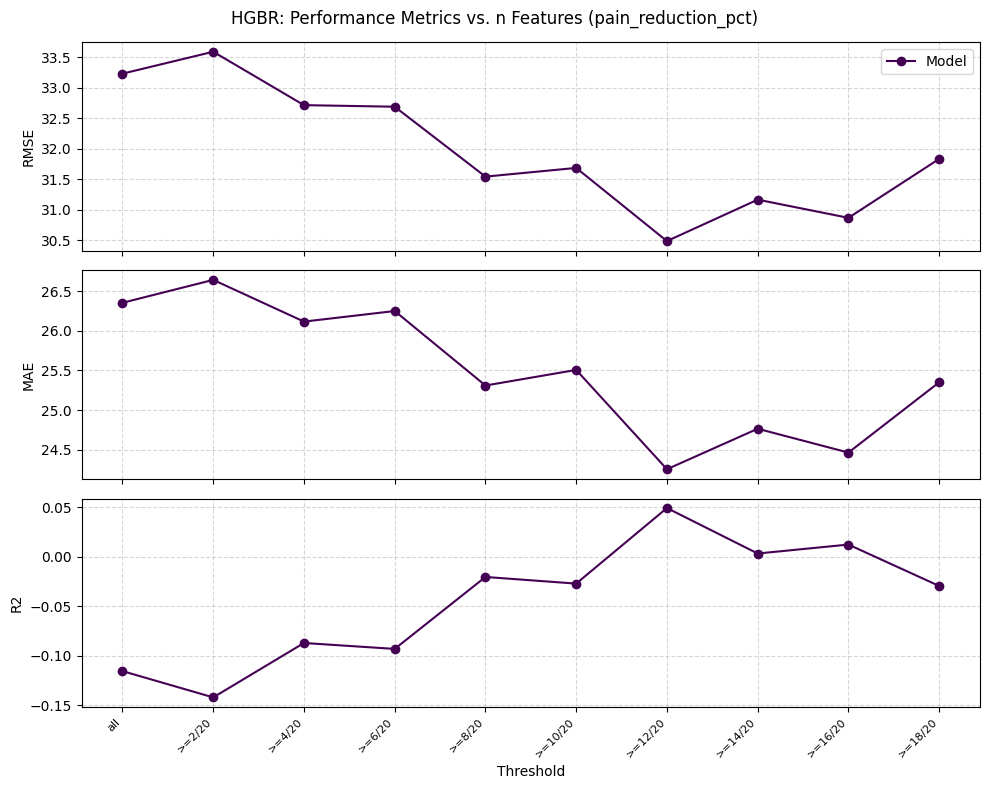

In [9]:
# Plot performances on different feature-tresholds
importlib.reload(model)
hgbr_sweep_df = joblib.load(os.path.join(MODEL_DIR, 'hgbr_sweep_df.pkl'))
model.plot_sweep(hgbr_sweep_df, title='HGBR: Performance Metrics vs. n Features (pain_reduction_pct)')

# Final HGBR Model
## Features Selected in >= 12/20 outer folds: 6 features

In [4]:
feature_list = joblib.load(os.path.join(MODEL_DIR, 'hgbr_feature_freq.pkl'))
# selecting features in more than 12/20 outer folds:
sel_features = feature_list[feature_list >= 12].index.tolist()

hgbr_results, hgbr_model, hgbr_X_final, hgbr_y_pred, hgbr_patient_err, hgbr_err_df, hgbr_scaler, hgbr_errors = model_hgbr.run_tuned_hgbr(
    df_pain, 
    sel_features,
    target_col='pain_reduction_pct', 
    random_state=42,
    target_transformer=pt)

# save results
joblib.dump(hgbr_results,                os.path.join(MODEL_DIR, 'hgbr_results.pkl'))
joblib.dump(hgbr_model,                os.path.join(MODEL_DIR, 'hgbr_model.pkl'))
joblib.dump(hgbr_X_final,              os.path.join(MODEL_DIR, 'hgbr_X_final.pkl'))
joblib.dump(hgbr_patient_err,          os.path.join(MODEL_DIR, 'hgbr_patient_err.pkl'))
joblib.dump(hgbr_err_df,               os.path.join(MODEL_DIR, 'hgbr_err_df.pkl'))
joblib.dump(hgbr_scaler,               os.path.join(MODEL_DIR, 'hgbr_scaler.pkl'))
joblib.dump(hgbr_errors,               os.path.join(MODEL_DIR, 'hgbr_errors.pkl'))


  HGBR + Optuna — pain_reduction_pct
  n=129, p=6
  Outer 4×5=20 | Inner 4×5=20 | Optuna trials=50

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
    Trial   1/50: RMSE=0.9504  {'max_depth': 3, 'learning_rate': 0.2536999076681772, 'min_samples_leaf': 25, 'l2_regularization': 0.5986584841970366, 'max_iter': 400}
    Trial   2/50: RMSE=0.9439  {'max_depth': 5, 'learning_rate': 0.11114989443094977, 'min_samples_leaf': 10, 'l2_regularization': 0.9699098521619943, 'max_iter': 100}
    Trial   3/50: RMSE=0.9334  {'max_depth': 3, 'learning_rate': 0.05958389350068958, 'min_samples_leaf': 19, 'l2_regularization': 0.2912291401980419, 'max_iter': 100}
    Trial   4/50: RMSE=0.8740  {'max_depth': 4, 'learning_rate': 0.14447746112718687, 'min_samples_leaf': 14, 'l2_regularization': 0.5142344384136116, 'max_iter': 300}
    Trial   5/50: RMSE=0.9332  {'max_depth': 2, 'learning_rate': 0.25212679047

['p:\\UK_Erlangen\\Student_folders\\Muna Ahmed Farah - IMMO-LDRT01\\master-thesis\\models\\pain-reduction\\hgbr_errors.pkl']

## SHAP-value Plot


=== SHAP Analysis: HGBR ===


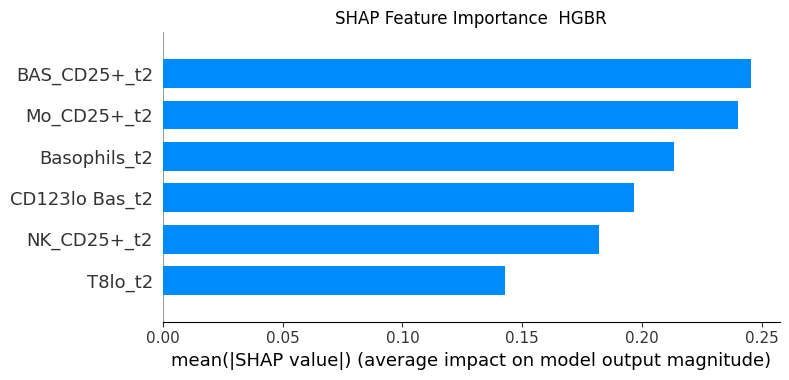

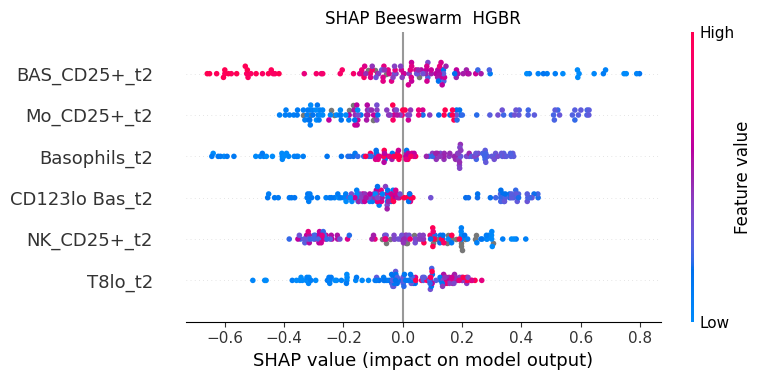

In [12]:
# Plot Shap values
hgbr_model= joblib.load(os.path.join(MODEL_DIR, 'hgbr_model.pkl'))
hgbr_X_final = joblib.load(os.path.join(MODEL_DIR, 'hgbr_X_final.pkl'))
hgbr_scaler = joblib.load(os.path.join(MODEL_DIR, 'hgbr_scaler.pkl'))

hgbr_shap = model.plot_shap_hgbr(hgbr_model, hgbr_X_final)

## Difficult Patient Predictions

In [8]:
patient_err = joblib.load(os.path.join(MODEL_DIR, 'hgbr_patient_err.pkl'))
print(patient_err.to_string())


difficult_patients = patient_err.head(10).index.tolist()

pain_data = (df_cl_mod[df_cl_mod['Patient'].isin(difficult_patients)]
             [['Patient', 'Timepoint', 'pain_scale']].pivot(index='Patient', columns='Timepoint', values='pain_scale'))
pain_data.columns = [f'pain_t{c}' for c in pain_data.columns]

difficult_df = (pain_data
                .merge(patient_err[['mean_mae']], left_index=True, right_index=True)
                .sort_values('mean_mae', ascending=False))[['pain_t1', 'pain_t2', 'mean_mae']]


print('Difficult Patient-Predictions and Pain Scale Values:')
display(difficult_df)

         mean_mae  mean_true  mean_pred  n_folds
Patient                                         
248        109.95    -100.00       9.95        5
258         72.50      75.00       2.50        5
72          65.54     -61.11       4.43        5
145         64.79     -66.67      -1.88        5
118         61.96      50.00     -11.96        5
230         59.25      65.00       5.75        5
240         55.02      70.00      14.98        5
203         54.95     -41.67      13.28        5
92          54.87     -16.39      38.47        5
132         52.13      66.67      14.53        5
143         49.77     -12.50      37.27        5
105         47.99      87.50      39.51        5
144         46.65     -28.57      18.08        5
137         45.46      57.14      11.68        5
256         44.99      57.14      12.16        5
127         44.92     -21.87      23.04        5
181         44.00      87.50      43.50        5
171         42.13      75.00      32.87        5
196         42.10   

,pain_t1,pain_t2,mean_mae
Patient,,,
248,4.0,8.0,109.95
258,4.0,1.0,72.50
72,1.8,2.9,65.54
145,3.0,5.0,64.79
118,6.0,3.0,61.96
230,10.0,3.5,59.25
240,5.0,1.5,55.02
203,6.0,8.5,54.95
92,6.1,7.1,54.87


## Prediction-Error Heatmap

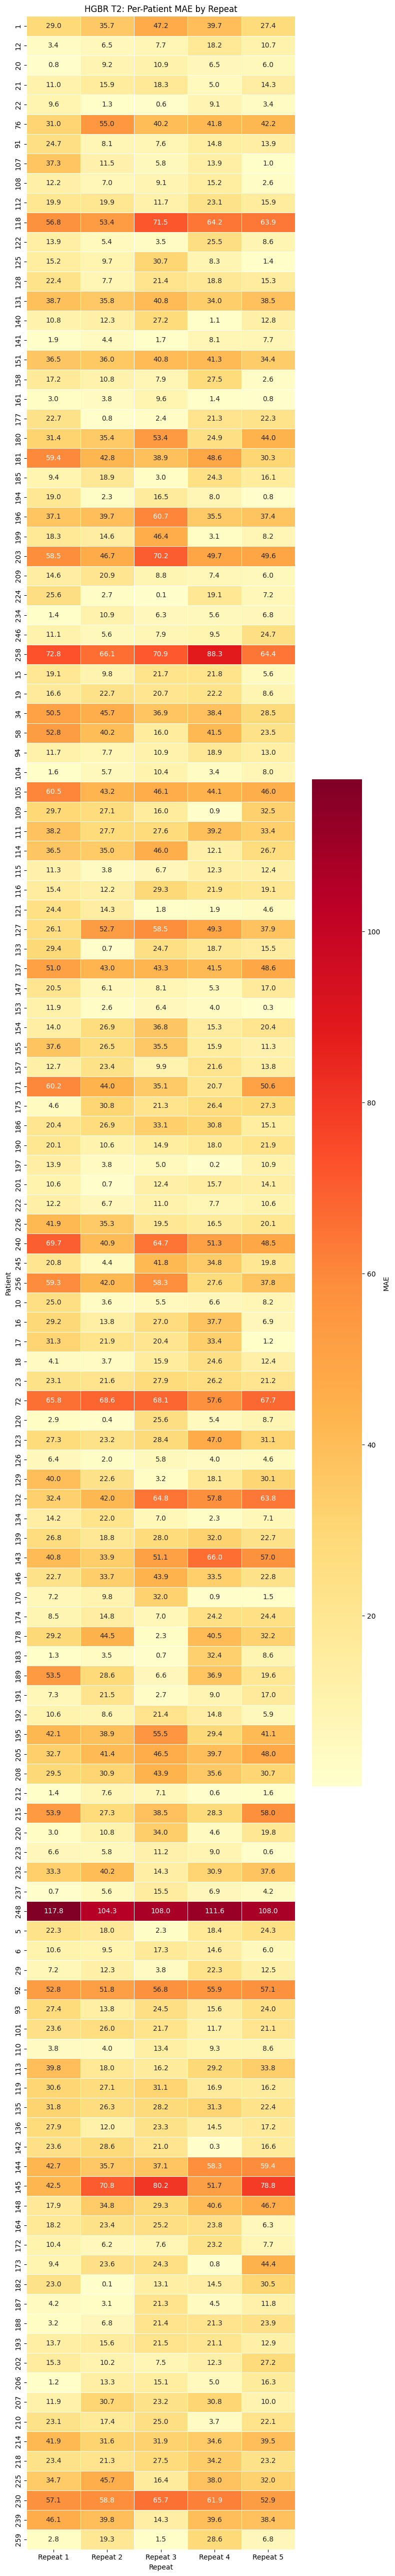

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
# Order by appearance across folds (fold 1 first, then fold 2, etc.)
seen = []

for e in hgbr_errors:
    if e['Patient'] not in seen:
        seen.append(e['Patient'])

heatmap_data = hgbr_err_df.loc[seen]

fig, ax = plt.subplots(figsize=(8, max(4, len(heatmap_data) * 0.4)))
sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'MAE'})
ax.set_title('HGBR T2: Per-Patient MAE by Repeat')
ax.set_xlabel('Repeat')
ax.set_ylabel('Patient')
plt.tight_layout()
plt.show()



## Patient-Sensitivity Analysis
### Removing top 5 difficult patients

In [16]:
top5difficult =  patient_err.head(5).index.tolist()
# filter away top 5 difficult patients from df pain>
df_pain_filtered= df_pain[~df_pain['Patient'].isin(top5difficult)]

feature_list = joblib.load(os.path.join(MODEL_DIR, 'hgbr_feature_freq.pkl'))
# selecting features in more than 12/20 outer folds:
sel_features = feature_list[feature_list >= 12].index.tolist()

hgbr_results, hgbr_model, hgbr_X_final, hgbr_y_pred, hgbr_patient_err, hgbr_scaler = model_hgbr.run_tuned_hgbr(
    df_pain_filtered, 
    sel_features,
    target_col='pain_reduction_pct', 
    random_state=42,
    target_transformer=pt)




  HGBR + Optuna — pain_reduction_pct
  n=124, p=6
  Outer 4×5=20 | Inner 4×5=20 | Optuna trials=50

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
    Trial   1/50: RMSE=1.0097  {'max_depth': 3, 'learning_rate': 0.2536999076681772, 'min_samples_leaf': 25, 'l2_regularization': 0.5986584841970366, 'max_iter': 400}
    Trial   2/50: RMSE=1.0086  {'max_depth': 5, 'learning_rate': 0.11114989443094977, 'min_samples_leaf': 10, 'l2_regularization': 0.9699098521619943, 'max_iter': 100}
    Trial   3/50: RMSE=0.9453  {'max_depth': 3, 'learning_rate': 0.05958389350068958, 'min_samples_leaf': 19, 'l2_regularization': 0.2912291401980419, 'max_iter': 100}
    Trial   4/50: RMSE=0.9781  {'max_depth': 4, 'learning_rate': 0.14447746112718687, 'min_samples_leaf': 14, 'l2_regularization': 0.5142344384136116, 'max_iter': 300}
    Trial   5/50: RMSE=1.0064  {'max_depth': 2, 'learning_rate': 0.25212679047

## HGBR model using most IMMO-LDRT01 Interim Analysis found Significant features

In [4]:
il_sel_features =[
    # Absolute cell numbers significantly changed by LDRT...
    'Basophils_t2',
    'CD123lo Bas_t2',
    'Eosinophils_t2',
    'PDCs_t2',
    'B cells_t2',
    # Activation markers significantly changed by LDRT....
    'Mo_CD25+_t2',
    'Mo3_HLADR+_t2',   
    'TH EM_PD1+_t2',
    # Features correlated with pain outcomes (monocytic lineage)....
    'mDC-1_t2',
    'Mo1_t2',
    'Mo3_t2',
]

il_hgbr_results, il_hgbr_model, il_hgbr_X_final, il_hgbr_y_pred, il_hgbr_patient_err, il_hgbr_scaler = model_hgbr.run_tuned_hgbr(
    df_pain, 
    il_sel_features,
    target_col='pain_reduction_pct', 
    random_state=42,
    target_transformer=pt)


  HGBR + Optuna — pain_reduction_pct
  n=129, p=11
  Outer 4×5=20 | Inner 4×5=20 | Optuna trials=50

─────────────────────────────────────────────────────────────────
  Outer fold 1/20
─────────────────────────────────────────────────────────────────
    Trial   1/50: RMSE=0.9990  {'max_depth': 3, 'learning_rate': 0.2536999076681772, 'min_samples_leaf': 25, 'l2_regularization': 0.5986584841970366, 'max_iter': 400}
    Trial   2/50: RMSE=1.0339  {'max_depth': 5, 'learning_rate': 0.11114989443094977, 'min_samples_leaf': 10, 'l2_regularization': 0.9699098521619943, 'max_iter': 100}
    Trial   3/50: RMSE=0.9509  {'max_depth': 3, 'learning_rate': 0.05958389350068958, 'min_samples_leaf': 19, 'l2_regularization': 0.2912291401980419, 'max_iter': 100}
    Trial   4/50: RMSE=1.0682  {'max_depth': 4, 'learning_rate': 0.14447746112718687, 'min_samples_leaf': 14, 'l2_regularization': 0.5142344384136116, 'max_iter': 300}
    Trial   5/50: RMSE=1.0172  {'max_depth': 2, 'learning_rate': 0.2521267904